In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def load_data(filename):
    graph = {}
    edges = []
    nodes = set()

    with open(filename, "r") as file:
        for line in file:
            if line.startswith("#"):
                continue
            node1, node2 = map(int, line.strip().split())

            nodes.update([node1, node2])
            edges.append((node1, node2))

            if node1 not in graph:
                graph[node1] = set()
            if node2 not in graph:
                graph[node2] = set()

            graph[node1].add(node2)
            graph[node2].add(node1)

    return graph, edges, sorted(nodes)

In [3]:
filename = "ca-GrQc.txt"
graph, edges, nodes = load_data(filename)

In [4]:
def generate_gilbert_graph(N, p):
    graph = {i: set() for i in range(N)}

    for i in range(N):
        for j in range(i + 1, N):
            if random.random() < p:  # Create edge with probability p
                graph[i].add(j)
                graph[j].add(i)

    return graph

In [5]:
N = len(nodes)
p = len(edges)/(N * (N-1) / 2)
gilbert_graph = generate_gilbert_graph(N, p)

In [6]:
def compute_degree_distribution(graph):
    degree_count = {}

    for node in graph:
        degree = len(graph[node])
        degree_count[degree] = degree_count.get(degree, 0) + 1

    total_nodes = len(graph)
    p_k = {k: v / total_nodes for k, v in degree_count.items()}
    
    return p_k

def plot_degree_distribution(graph, filename):
    p_k = compute_degree_distribution(graph)
    
    degrees = np.array(list(p_k.keys()))
    probabilities = np.array(list(p_k.values()))

    plt.figure(figsize=(7, 5))
    plt.scatter(degrees, probabilities * degrees, color='blue', alpha=0.6, label=r"$p_k \times k$")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Degree (k)")
    plt.ylabel(r"$p_k \times k$")
    plt.title("Scaled Degree Distribution (Gilbert Graph)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    
    plt.savefig(filename, dpi=300)

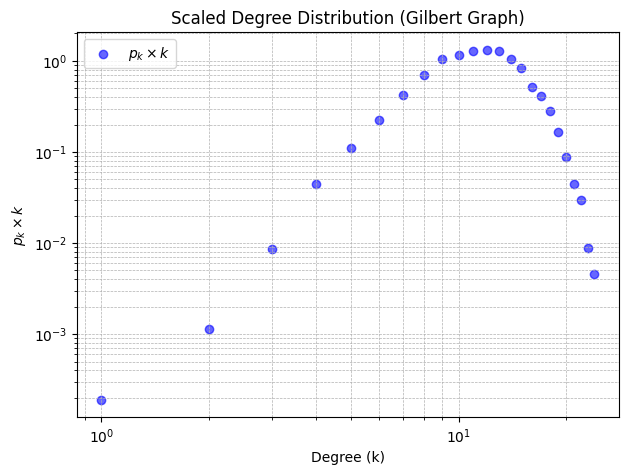

In [7]:
plot_degree_distribution(gilbert_graph, "degree_distribution_gilbert.png")

In [8]:
def compare_degree_distributions(real_graph, gilbert_graph):
    p_k_real = compute_degree_distribution(real_graph)
    p_k_gilbert = compute_degree_distribution(gilbert_graph)

    degrees_real = np.array(list(p_k_real.keys()))
    probabilities_real = np.array(list(p_k_real.values()))

    degrees_gilbert = np.array(list(p_k_gilbert.keys()))
    probabilities_gilbert = np.array(list(p_k_gilbert.values()))

    plt.figure(figsize=(7, 5))
    plt.scatter(degrees_real, probabilities_real * degrees_real, color='red', alpha=0.6, label="Real Network")
    plt.scatter(degrees_gilbert, probabilities_gilbert * degrees_gilbert, color='blue', alpha=0.6, label="Gilbert Graph")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Degree (k)")
    plt.ylabel(r"$p_k \times k$")
    plt.title("Comparison of Scaled Degree Distributions")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    plt.savefig("degree_distribution_comparison.png", dpi=300)

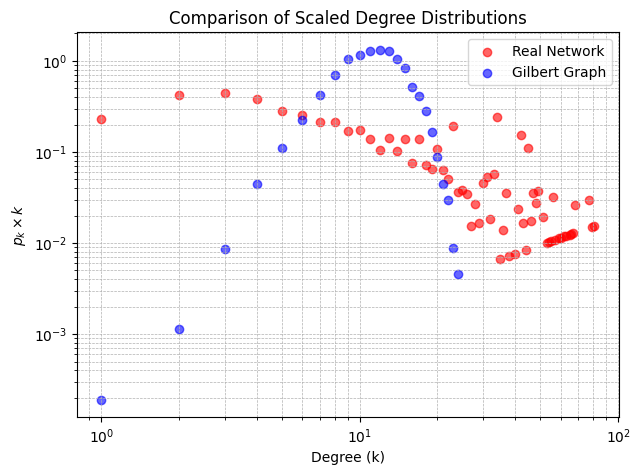

In [9]:
compare_degree_distributions(graph, gilbert_graph)

In [10]:
def generate_gilbert_graph_instances(N, p, num_instances):
    graphs = [generate_gilbert_graph(N, p) for _ in range(num_instances)]
    return graphs

def compute_average_degree_distribution(graphs):
    total_p_k = {}

    for graph in graphs:
        p_k = compute_degree_distribution(graph)
        for k, v in p_k.items():
            if k not in total_p_k:
                total_p_k[k] = []
            total_p_k[k].append(v)

    avg_p_k = {k: np.mean(v) for k, v in total_p_k.items()}
    return avg_p_k

def plot_degree_distributions_gilbert_graph_instances(graphs, filename):
    avg_p_k = compute_average_degree_distribution(graphs)

    degrees = np.array(list(avg_p_k.keys()))
    probabilities = np.array(list(avg_p_k.values()))

    plt.figure(figsize=(7, 5))
    plt.scatter(degrees, probabilities * degrees, color='purple', alpha=0.6, label="Gilbert Graph (100 instances)")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Degree (k)")
    plt.ylabel(r"$p_k \times k$")
    plt.title("Degree Distribution for 100 Gilbert Graphs")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    plt.savefig(filename, dpi=300)

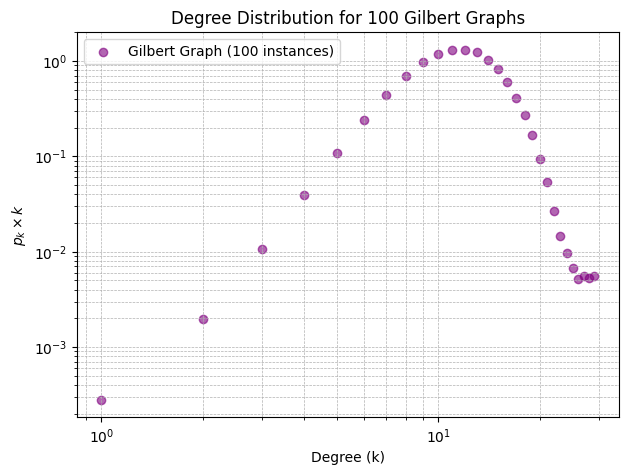

In [11]:
# Generate 100 Gilbert graph instances
num_instances = 100
gilbert_graphs = generate_gilbert_graph_instances(N, p, num_instances)
plot_degree_distributions_gilbert_graph_instances(gilbert_graphs, "degree_distribution_100_gilbert.png")